In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv('../../../data/processed/land_dataset_final_v3_noisy_3.csv')

# Drop unwanted columns
X = df.drop(columns=['price_per_m2', 'price', 'longitude', 'latitude', 'geometry', 'land_area'])
y = df['price_per_m2']


In [49]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [50]:
X_raw = X.copy()
var_thresh = VarianceThreshold(threshold=0.01)
X_var = var_thresh.fit_transform(X_raw)

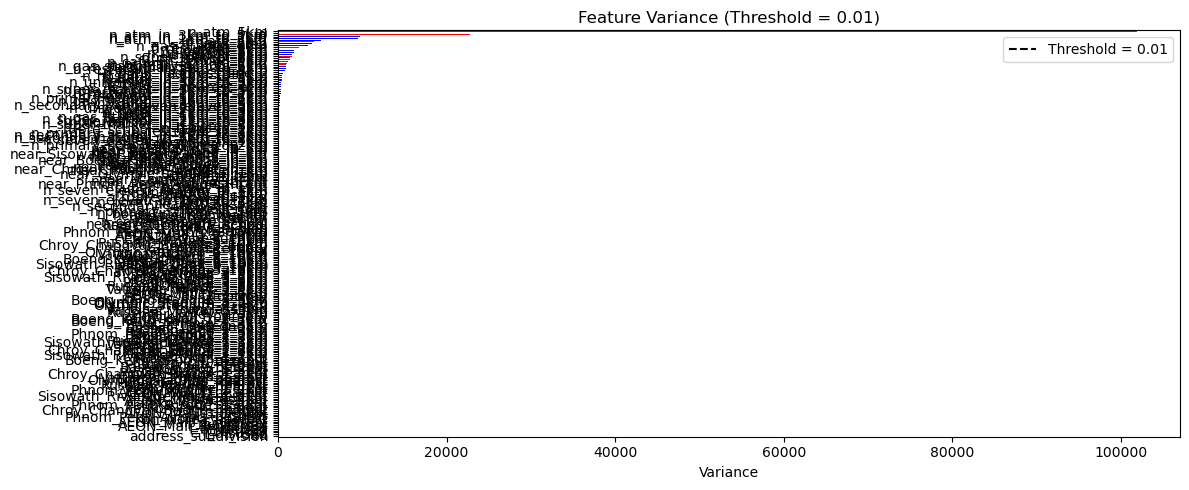

In [51]:
variances = pd.Series(var_thresh.variances_, index=X_raw.columns)
plt.figure(figsize=(12, 5))
variances.sort_values().plot(kind='barh', color=['red' if v < 0.01 else 'blue' for v in variances])
plt.axvline(0.01, color='black', linestyle='--', label='Threshold = 0.01')
plt.title("Feature Variance (Threshold = 0.01)")
plt.xlabel("Variance")
plt.tight_layout()
plt.legend()
plt.show()

In [53]:
X = pd.DataFrame(X_var, columns=X_raw.columns[var_thresh.get_support()])


In [54]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X = X.drop(columns=to_drop)

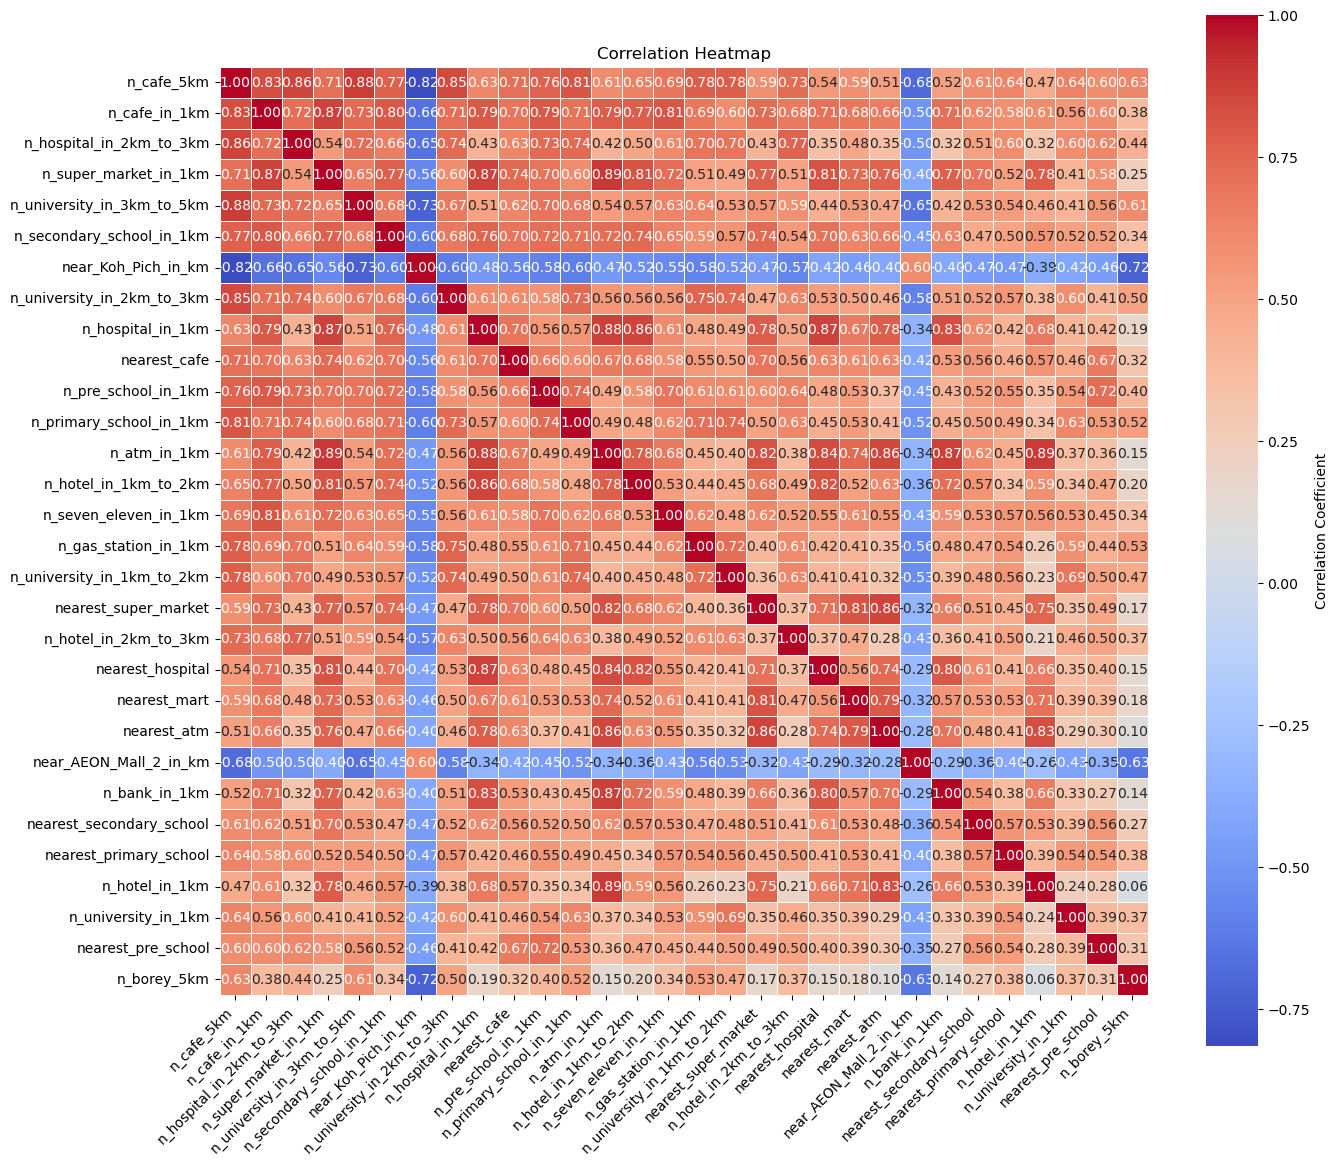

In [59]:
# Compute correlation matrix for top 40 features (based on max absolute correlation values)
corr_matrix = X.corr().abs()

# Calculate total correlation for each feature
feature_correlation_strength = corr_matrix.sum().sort_values(ascending=False)

# Select top 40 most "correlated" features
top_features = feature_correlation_strength.head(30).index
top_corr = X[top_features].corr()

# Plot heatmap for top 40
plt.figure(figsize=(14, 12))
sns.heatmap(top_corr, cmap="coolwarm", annot=True, fmt=".2f", square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


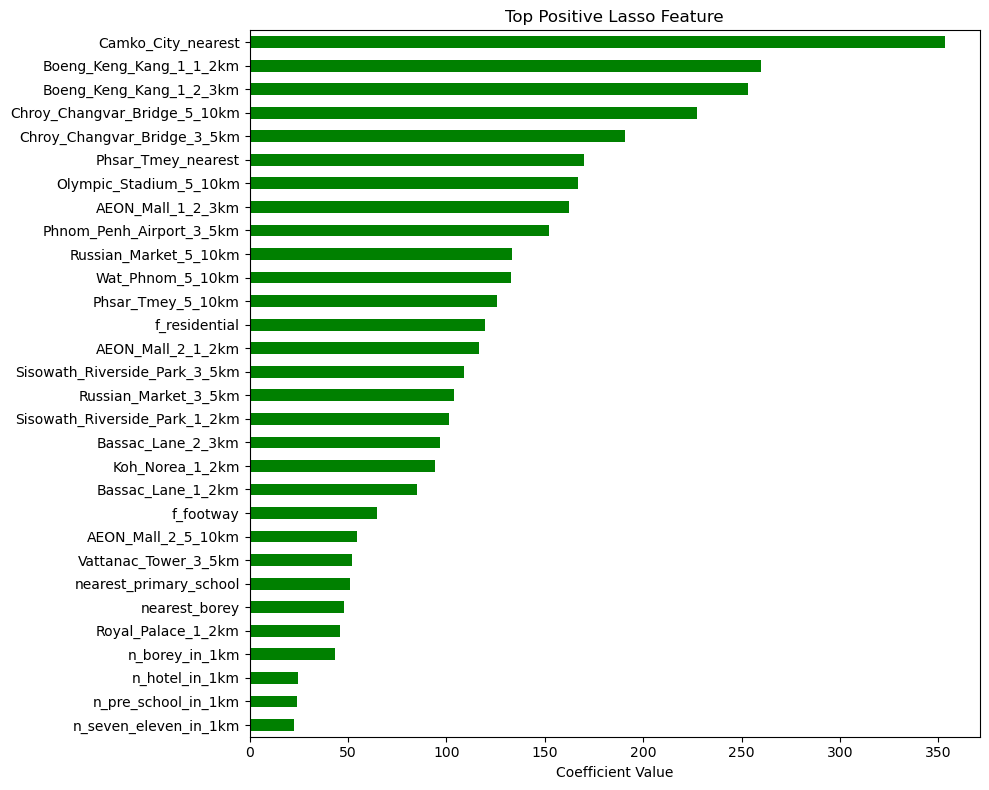

In [64]:

# Fit Lasso model
lasso = LassoCV(alphas=np.logspace(-4, 0, 100), cv=5, max_iter=10000)
lasso.fit(X, y)

# Create full coefficient series before modifying X
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)

# Filter for positive coefficients only and get top 30
positive_top_30 = lasso_coefs[lasso_coefs > 0].sort_values(ascending=False).head(30)

# Plot
plt.figure(figsize=(10, 8))
positive_top_30.sort_values().plot(kind='barh', color='green')
plt.title("Top Positive Lasso Feature")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

# Apply selection mask to X
coef_mask = lasso.coef_ != 0
X = X.loc[:, coef_mask]

In [68]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
top_15_rf = rf_importances.sort_values(ascending=False).head(15)


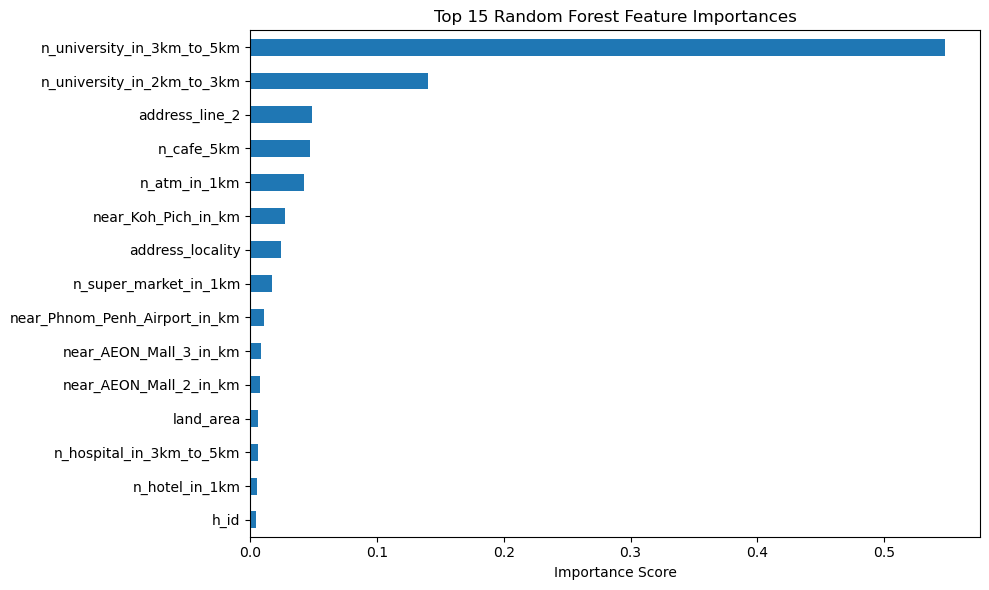

In [70]:
plt.figure(figsize=(10, 6))
top_15_rf.sort_values().plot(kind='barh')
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [67]:
final_features = X.columns.tolist()
print("Final selected features:")
print(final_features)

Final selected features:
['address_locality', 'address_line_2', 'h_id', 'land_area', 'near_Koh_Pich_in_km', 'Koh_Pich_3_5km', 'Koh_Pich_5_10km', 'Russian_Market_3_5km', 'Russian_Market_5_10km', 'AEON_Mall_1_nearest', 'AEON_Mall_1_2_3km', 'AEON_Mall_1_5_10km', 'near_AEON_Mall_2_in_km', 'AEON_Mall_2_1_2km', 'AEON_Mall_2_3_5km', 'AEON_Mall_2_5_10km', 'near_AEON_Mall_3_in_km', 'AEON_Mall_3_2_3km', 'AEON_Mall_3_3_5km', 'AEON_Mall_3_5_10km', 'Bassac_Lane_1_2km', 'Bassac_Lane_2_3km', 'Bassac_Lane_3_5km', 'Koh_Norea_1_2km', 'Koh_Norea_2_3km', 'Koh_Norea_3_5km', 'Camko_City_nearest', 'Camko_City_5_10km', 'Olympic_Stadium_1_2km', 'Olympic_Stadium_3_5km', 'Olympic_Stadium_5_10km', 'Phsar_Tmey_nearest', 'Phsar_Tmey_1_2km', 'Phsar_Tmey_5_10km', 'Boeng_Keng_Kang_1_nearest', 'Boeng_Keng_Kang_1_1_2km', 'Boeng_Keng_Kang_1_2_3km', 'Boeng_Keng_Kang_1_3_5km', 'Wat_Phnom_3_5km', 'Wat_Phnom_5_10km', 'Chroy_Changvar_Bridge_1_2km', 'Chroy_Changvar_Bridge_2_3km', 'Chroy_Changvar_Bridge_3_5km', 'Chroy_Changvar_